In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("charts", exist_ok=True)

# Display all columns
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head(10)

Dataset Loaded Successfully!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [66]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 1470
Columns: 35

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [67]:
print("Target Column: Attrition")

print("\nAttrition Count:")
print(df['Attrition'].value_counts())

Target Column: Attrition

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [68]:
attrition_rate = (
    df['Attrition']
    .value_counts(normalize=True)
    *100
)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [69]:
numeric_cols = df.select_dtypes(include='number').columns

categorical_cols = df.select_dtypes(exclude='number').columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

print("\nCategorical Columns:")
print(categorical_cols.tolist())

Numeric Columns: 26
Categorical Columns: 9

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


Observation:

The dataset contains 1,470 employee records and 35 features. The target variable is Attrition, which indicates whether an employee left the company (Yes) or stayed (No). Approximately 16% of employees left the company, while 84% stayed, showing that the dataset is imbalanced. This imbalance should be considered during model training to avoid biased predictions.

In [70]:
# Check missing values

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [71]:
print("Total Missing Values:")
print(df.isnull().sum().sum())

Total Missing Values:
0


In [72]:
original_df = df.copy()

In [73]:
# Drop irrelevant columns

df.drop(
    [
        'EmployeeNumber',
        'EmployeeCount',
        'Over18',
        'StandardHours'
    ],
    axis=1,
    inplace=True
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [74]:
# Convert Attrition to 0 and 1

df['Attrition'] = df['Attrition'].map({
    'No':0,
    'Yes':1
})

df['Attrition'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [75]:
# Encode categorical variables

df = pd.get_dummies(
    df,
    drop_first=True
)

print("New Shape:", df.shape)
df.head()

New Shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


In [76]:
X = df.drop(
    'Attrition',
    axis=1
)

y = df['Attrition']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1470, 44)
y Shape: (1470,)


In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [132]:
department_attrition = pd.crosstab(
    original_df['Department'],
    original_df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


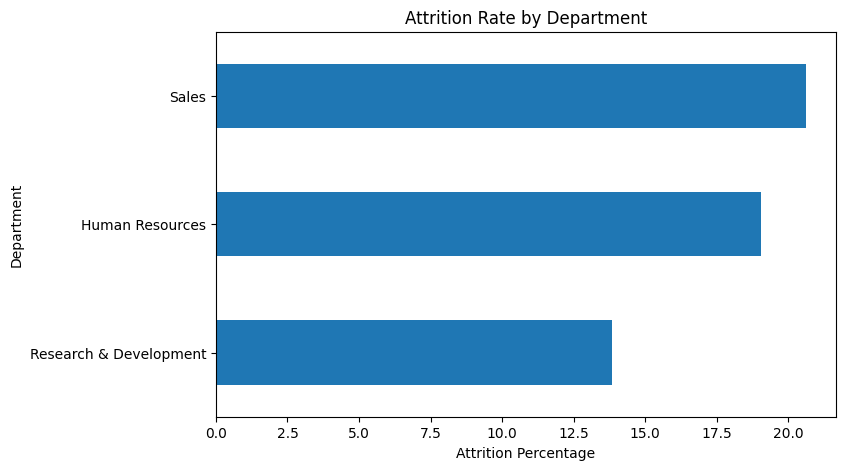

In [134]:
department_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Percentage")
plt.savefig("charts/attrition_by_department.png", bbox_inches='tight')
plt.show()

In [ ]:
jobrole_attrition = pd.crosstab(
    original_df['JobRole'],
    original_df['Attrition'],
    normalize='index'
) * 100

jobrole_attrition.sort_values(
    by='Yes',
    ascending=False
)

In [ ]:
jobrole_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Percentage")
plt.savefig("charts/attrition_by_jobrole.png", bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=original_df
)

plt.title("Monthly Income vs Attrition")
plt.savefig("charts/monthly_income_vs_attrition.png", bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=original_df
)

plt.title("Work-Life Balance vs Attrition")
plt.savefig("charts/worklife_balance_vs_attrition.png", bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=original_df
)

plt.title("Years At Company vs Attrition")
plt.savefig("charts/years_at_company_vs_attrition.png", bbox_inches='tight')
plt.show()

Business Insights from EDA
1. Sales department has the highest attrition rate (20.63%), followed by Human Resources (19.05%), while Research & Development has the lowest attrition rate (13.84%). This suggests that employee retention efforts should be prioritized in Sales and HR teams.
2. Sales Representatives experience the highest employee attrition rate (39.76%), which is nearly double the overall company attrition rate. Laboratory Technicians (23.94%) and HR employees (23.08%) also show relatively high turnover.
3. Employees who left the company generally have lower monthly incomes compared to employees who stayed, indicating that compensation may influence retention decisions.
4. Employees with fewer years at the company are more likely to leave, while employees with longer tenure show significantly lower attrition. This suggests that employee turnover is highest during the early years of employment.
5. Work-Life Balance appears to affect employee retention. Employees reporting lower work-life balance levels show relatively higher attrition compared to employees with better work-life balance ratings.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [147]:
lr = LogisticRegression( class_weight='balanced', max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [148]:
rf = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [149]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:,1]

In [150]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Precision':[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    'Recall':[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    'F1 Score':[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    'ROC AUC':[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.444444,0.085106,0.142857,0.772590
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


In [151]:
results.sort_values(
    by='ROC AUC',
    ascending=False
)

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.345238,0.617021,0.442748,0.798260
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125
1,Random Forest,0.444444,0.085106,0.142857,0.772590


Observation:

Among the three models tested, Logistic Regression performed the best overall with the highest ROC-AUC score (0.798) and F1-Score (0.443). It also achieved the highest recall (61.7%), meaning it was better at identifying employees who were likely to leave the company. Since predicting potential attrition cases is more important than maximizing overall accuracy, Logistic Regression was selected as the final model for further analysis.

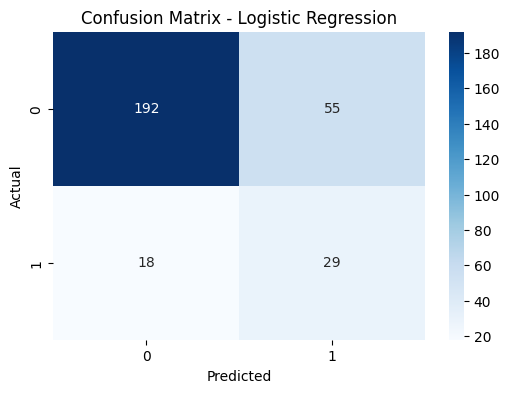

In [152]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("charts/confusion_matrix.png", bbox_inches='tight')

plt.show()

In [153]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred)
)

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [154]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


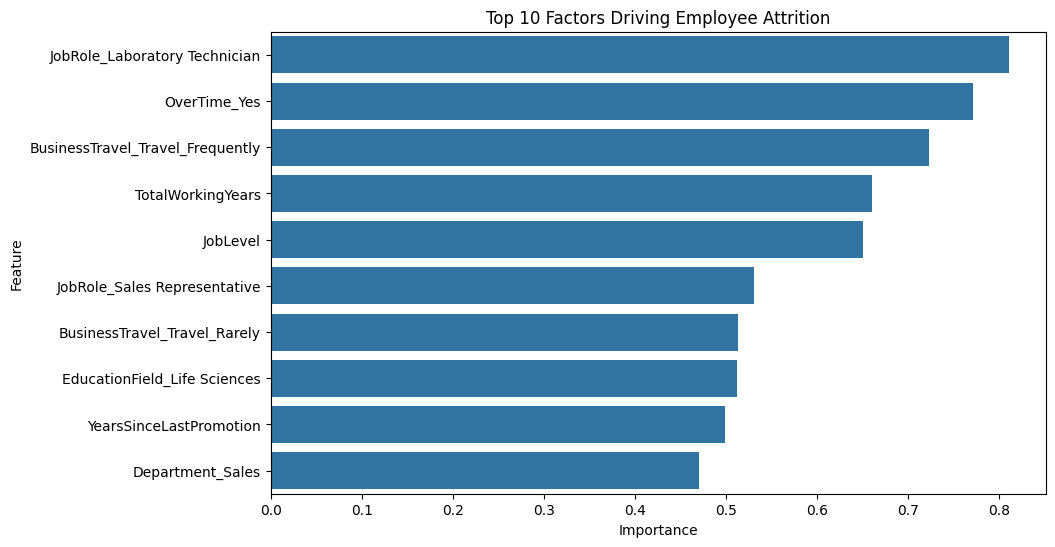

In [155]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Factors Driving Employee Attrition")
plt.savefig("charts/top10_feature_importance.png", bbox_inches='tight')
plt.show()

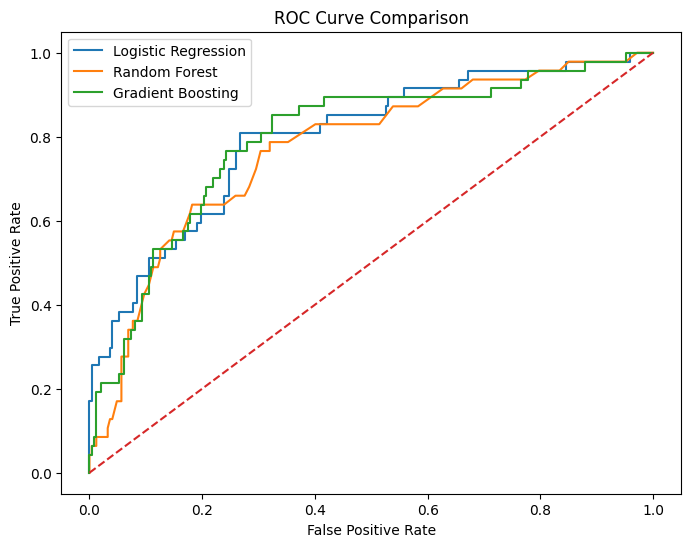

In [156]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for model_name, prob in [
    ("Logistic Regression", lr_prob),
    ("Random Forest", rf_prob),
    ("Gradient Boosting", gb_prob)
]:

    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        label=model_name
    )

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.savefig("charts/roc_curve_comparison.png", bbox_inches='tight')
plt.legend()

plt.show()

In [157]:
import os

os.listdir("charts")

['.ipynb_checkpoints',
 'attrition_by_department.png',
 'attrition_by_jobrole.png',
 'confusion_matrix.png',
 'monthly_income_vs_attrition.png',
 'roc_curve_comparison.png',
 'top10_feature_importance.png',
 'worklife_balance_vs_attrition.png',
 'years_at_company_vs_attrition.png']

                                         HR Insights & Recommendations

Based on the analysis, employee attrition is influenced by multiple factors rather than salary alone. The most important predictors identified by the model were Laboratory Technician role, Overtime, Frequent Business Travel, Total Working Years, and Job Level. Employees working overtime and those who travel frequently for business were more likely to leave the company. The EDA also showed that Sales Representatives had the highest attrition rate (39.76%), while the Sales department recorded the highest departmental attrition rate (20.63%).

Although lower monthly income was associated with higher attrition, compensation was not the only factor affecting employee turnover. Work-life balance, job role, promotion opportunities, and workload also played important roles. Employees with fewer years at the company were more likely to leave, suggesting that retention efforts should focus on early-career employees.
    
To reduce attrition, HR should first prioritize employees in high-risk roles such as Sales Representatives and Laboratory Technicians through regular engagement, mentoring, and career development programs. Second, the company should review overtime policies and workload distribution to improve work-life balance and reduce employee burnout.

One limitation of this model is that it is based on historical employee data and may not capture personal reasons for leaving, such as family circumstances, career changes, or external job opportunities. Therefore, the model should be used as a decision-support tool rather than the sole basis for HR decisions.

                                                Model Limitations
1. Dataset contains historical HR records only.
2. Personal reasons for resignation are not captured.
3. External market conditions are unavailable.
4. Results are specific to the IBM HR dataset and may require retraining for other organizations.
5. Attrition behavior can change over time, requiring periodic model updates.

                                          Project Conclusion

This project successfully developed a machine learning system to predict employee attrition using HR analytics data. After cleaning and preprocessing the dataset, multiple classification models were trained and compared. Logistic Regression achieved the best overall performance with an ROC-AUC score of approximately 0.80 and was selected as the final model.

The analysis revealed that overtime, business travel frequency, job role, job level, and promotion history are among the most important factors influencing employee attrition. Employees in Sales-related roles and those with higher workloads showed a greater tendency to leave the organization.

The findings demonstrate how machine learning can help HR departments identify employees at risk of attrition and implement proactive retention strategies. By using data-driven insights, organizations can improve employee satisfaction, reduce turnover costs, and make better workforce management decisions.